In [1]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [14]:
class LensDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
            self.df = df.reset_index(drop=True)
            self.image_dir = image_dir
            self.transform = transform

    def __len__(self):
            return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.load(os.path.join(self.image_dir, row['filename']))
        
        # Normalize to [0, 1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        # ResNet expects 3 channels — repeat single channel 3 times
        img = np.stack([img, img, img], axis=0).astype(np.float32)
        img = torch.from_numpy(img)
        img = F.interpolate(img.unsqueeze(0), size=(224, 224), mode='bicubic', align_corners=False).squeeze(0)
        
        label = torch.tensor(row['label'], dtype=torch.float32)
        return torch.tensor(img), label

In [6]:
def get_dataloaders(train_csv, train_image_dir, test_csv, test_image_dir, val_csv, val_image_dir,
                     batch_size=32, val_split=0.2):
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    val_df = pd.read_csv(val_csv)
    
    
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    
    train_dataset = LensDataset(train_df, train_image_dir)
    val_dataset   = LensDataset(val_df, val_image_dir)
    test_dataset  = LensDataset(test_df, test_image_dir)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, test_df, val_df

In [16]:
train_loader, val_loader, test_loader, test_df, val_df = get_dataloaders(
    train_csv='lens_project/training_metadata.csv',
    train_image_dir='lens_project/training_images',
    test_csv='lens_project/testing_metadata.csv',
    test_image_dir='lens_project/testing_images',
    val_csv='lens_project/validation_metadata.csv',
    val_image_dir='lens_project/validation_images'
)
# images, labels = next(iter(train_loader))
# print(f"Batch shape: {images.shape}")
# print(f"Labels: {labels[:8]}")

Train: 800 | Val: 150 | Test: 500


In [9]:
import torch
import torch.nn as nn
import torchvision.models as models

def build_model():
    model = models.resnet18(weights='IMAGENET1K_V1')
    
    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace the head
    model.fc = nn.Linear(model.fc.in_features, 1)
    
    # Unfreeze just the new head
    for param in model.fc.parameters():
        param.requires_grad = True
    
    return model

In [10]:
model = build_model()

# Check which parameters are trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")

Trainable parameters: 513
Total parameters: 11,177,025


In [11]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.fc.parameters(), lr=0.0001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

In [12]:
import torch.nn as nn
fresh_layer = nn.Linear(512, 1)
print(f"Fresh layer weight min/max: {fresh_layer.weight.min().item()}, {fresh_layer.weight.max().item()}")

Fresh layer weight min/max: -0.04399547725915909, 0.04413590580224991


In [17]:
num_epochs = 30
train_losses, train_acc_list, test_acc_list = [], [], []
if torch.cuda.is_available():
    device = torch.device("cuda")
    model.to(device)
else:
    device = torch.device("cpu")

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
print(f"Raw output min: {outputs.min().item()}")
print(f"Raw output max: {outputs.max().item()}")
print(f"Raw output mean: {outputs.mean().item()}")
print(f"Sample outputs: {outputs[:5].squeeze()}")


best_loss = float('inf')
for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(1), labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        probs = torch.sigmoid(outputs.squeeze())
        predicted = (probs > 0.5).float()
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total

    model.eval()
    correct, total, val_total, val_correct, val_running_loss = 0, 0, 0, 0, 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs.squeeze())
            predicted = (probs > 0.5).float()
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_running_loss += criterion(outputs.squeeze(1), labels).item() * inputs.size(0)
            probs = torch.sigmoid(outputs.squeeze())
            predicted = (probs > 0.5).float()
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / len(val_loader.dataset)
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Best model saved with val_loss: {best_loss:.4f}")
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    val_acc = 100. * val_correct / val_total
    test_acc = 100. * correct / total
    test_acc_list.append(test_acc)
    
    scheduler.step()
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

/var/folders/n8/5ml0c6yx71j6f4dn3hvpw_zm0000gn/T/ipykernel_1526/149517578.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img), label


Raw output min: -0.9461148381233215
Raw output max: 1.0905518531799316
Raw output mean: 0.0025933198630809784
Sample outputs: tensor([ 0.4469, -0.1138, -0.2267, -0.6523, -0.2245],
       grad_fn=<SqueezeBackward0>)
Best model saved with val_loss: 0.8750
Epoch [1/30] Train Loss: 0.7982 | Train Acc: 28.75% | Test Acc: 37.40% | Val Loss: 0.8750 | Val Acc: 42.00%
Best model saved with val_loss: 0.7433
Epoch [2/30] Train Loss: 0.5591 | Train Acc: 84.25% | Test Acc: 41.20% | Val Loss: 0.7433 | Val Acc: 43.33%
Best model saved with val_loss: 0.6483
Epoch [3/30] Train Loss: 0.4045 | Train Acc: 97.50% | Test Acc: 67.40% | Val Loss: 0.6483 | Val Acc: 61.33%
Best model saved with val_loss: 0.4749
Epoch [4/30] Train Loss: 0.3026 | Train Acc: 99.50% | Test Acc: 85.80% | Val Loss: 0.4749 | Val Acc: 82.67%
Best model saved with val_loss: 0.3662
Epoch [5/30] Train Loss: 0.2520 | Train Acc: 99.62% | Test Acc: 88.60% | Val Loss: 0.3662 | Val Acc: 86.67%
Best model saved with val_loss: 0.3519
Epoch [6/30

In [18]:
# Load best weights from your saved checkpoint
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [19]:
# asisng redshift value to the image in the test set
model.eval()
results = []
idx = 0  # tracks position in test_df

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs.squeeze(1))
        
        batch_size = inputs.size(0)
        for i in range(batch_size):
            # what goes here? think about:
            # - how to get this specific image's redshift from test_df using idx+i
            redshift = test_df.iloc[idx + i]['source_redshift']
            # - how to get this specific image's true label (you already have it in `labels`)
            true_label = labels[i].item()
            # - how to get this specific image's predicted probability (you have it in `probs`)
            predicted_prob = probs[i].item()
            results.append({'redshift': redshift, 'true_label': true_label, 'predicted_prob': predicted_prob, "filename": test_df.iloc[idx + i]['filename']})
            pass
        
        idx += batch_size

/var/folders/n8/5ml0c6yx71j6f4dn3hvpw_zm0000gn/T/ipykernel_1526/149517578.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(img), label


In [20]:
results_df = pd.DataFrame(results)
lens_results = results_df[results_df['true_label'] == 1].copy()

In [21]:
bins = [0.2, 0.6, 1.0, 1.4, 1.8, 2.2]
lens_results['redshift_bin'] = pd.cut(lens_results['redshift'], bins=bins)
lens_results['predicted_label'] = (lens_results['predicted_prob'] > 0.5).astype(int)
bin_accuracy = lens_results.groupby('redshift_bin', observed=False)['predicted_label'].mean()
print(bin_accuracy)

redshift_bin
(0.2, 0.6]    1.000000
(0.6, 1.0]    1.000000
(1.0, 1.4]    0.929825
(1.4, 1.8]    0.568966
(1.8, 2.2]    0.166667
Name: predicted_label, dtype: float64


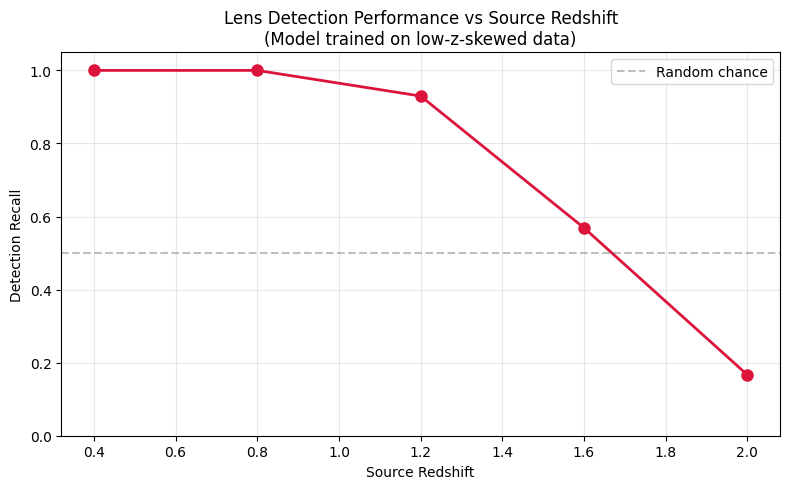

In [22]:
bin_centers = [0.4, 0.8, 1.2, 1.6, 2.0]  # midpoints of your bins

plt.figure(figsize=(8,5))
plt.plot(bin_centers, bin_accuracy.values, marker='o', linewidth=2, markersize=8, color='crimson')
plt.xlabel('Source Redshift')
plt.ylabel('Detection Recall')
plt.title('Lens Detection Performance vs Source Redshift\n(Model trained on low-z-skewed data)')
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random chance')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Check mean pixel values of high-z vs mid-z lens images
high_z = lens_results[lens_results['redshift'] > 1.8]
mid_z = lens_results[(lens_results['redshift'] > 1.4) & (lens_results['redshift'] <= 1.8)]

print(f"High-z mean predicted prob: {high_z['predicted_prob'].mean():.3f}")
print(f"Mid-z mean predicted prob: {mid_z['predicted_prob'].mean():.3f}")

High-z mean predicted prob: 0.343
Mid-z mean predicted prob: 0.522


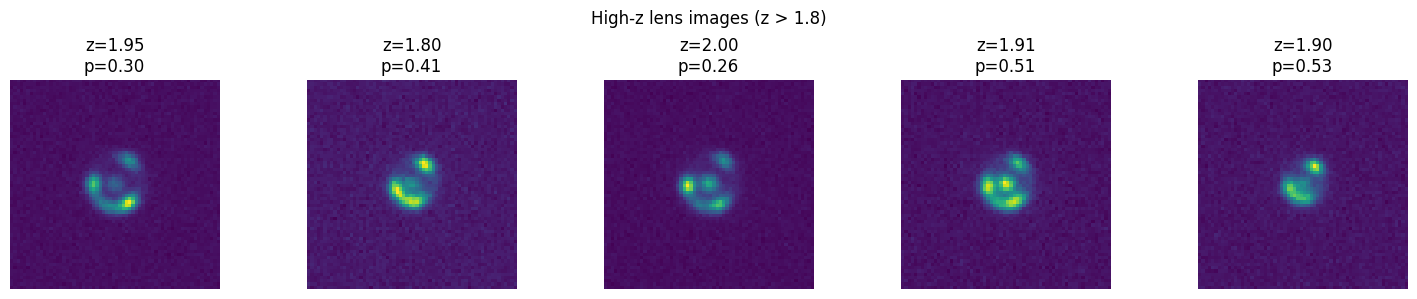

In [24]:
high_z_samples = lens_results[lens_results['redshift'] > 1.8].head(5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (_, row) in enumerate(high_z_samples.iterrows()):
    img = np.load(f'lens_project/testing_images/{row["filename"]}')
    axes[i].imshow(img, cmap='viridis', origin='lower')
    axes[i].set_title(f'z={row["redshift"]:.2f}\np={row["predicted_prob"]:.2f}')
    axes[i].axis('off')
plt.suptitle('High-z lens images (z > 1.8)')
plt.tight_layout()
plt.show()

In [25]:
print(lens_results['redshift_bin'].value_counts().sort_index())

redshift_bin
(0.2, 0.6]    49
(0.6, 1.0]    62
(1.0, 1.4]    57
(1.4, 1.8]    58
(1.8, 2.2]    24
Name: count, dtype: int64


In [26]:
lens_results.groupby('redshift_bin', observed=False)['predicted_prob'].mean()

redshift_bin
(0.2, 0.6]    0.970948
(0.6, 1.0]    0.905942
(1.0, 1.4]    0.756870
(1.4, 1.8]    0.522220
(1.8, 2.2]    0.343040
Name: predicted_prob, dtype: float64

In [27]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(results_df['true_label'], results_df['predicted_prob'])
print(f"Overall AUC-ROC: {auc:.3f}")

Overall AUC-ROC: 1.000
